# Looking at number of low-firing neurons

Comparing delay 50 vs delay 150

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *

2025-06-23 02:47:09.099343: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-23 02:47:09.108379: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-23 02:47:09.117772: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-23 02:47:09.120733: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-23 02:47:09.129209: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delays = [50, 150]
condn_phrase = 'delay'

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)


['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_011809', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225459', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_165543', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_221440', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_175711', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204320', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212723', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032739', 'Task_x

In [4]:
# get list of models with performance btwn 60-90% for longer delay

bad_models, bad_perfs = ld.get_models_by_perf(low_cutoff=0.60, high_cutoff=0.90, 
                                              condn_phrase='delay', condn_num=150)
print(len(bad_models), 'models with performance between 60-90% for delay 150')

Found 75 models with performance between 0.6 and 0.9
75 models with performance between 60-90% for delay 150


In [6]:
num_lowfr_50 = np.zeros(len(bad_models))
num_lowfr_150 = np.zeros(len(bad_models))
for i, model_name in enumerate(bad_models):
    lowfr_50 = ld.load_lowfr_idxs(model_name, 'delay', condn_num=50, threshold=2)
    lowfr_150 = ld.load_lowfr_idxs(model_name, 'delay', condn_num=150, threshold=2)
    num_lowfr_50[i] = len(lowfr_50)
    num_lowfr_150[i] = len(lowfr_150)

No files found with keywords ['lowfr', 'delay150', '2'] in /home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_165543
No files found with keywords ['lowfr', 'delay50', '2'] in /home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_175711
No files found with keywords ['lowfr', 'delay150', '2'] in /home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_175711
No files found with keywords ['lowfr', 'delay50', '2'] in /home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212723
No files found with keywords ['lowfr', 'delay150', '2'] in /home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212723
No files found with keywords ['lowfr', 'delay50', '2'] in /home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449
No file

Wilcoxon signed-rank test: stat = 3.0 , pval = 5.502676056881802e-14


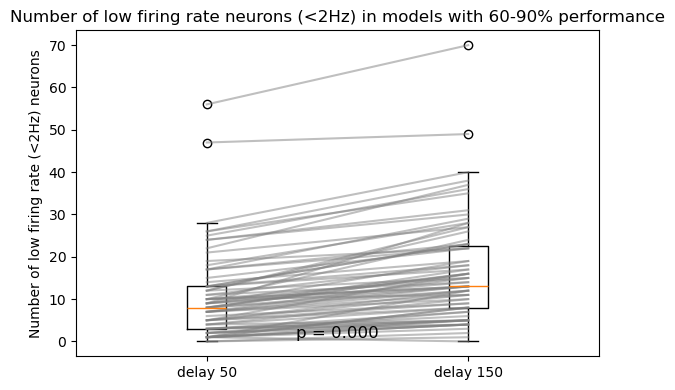

In [7]:
# make paired boxplot
plt.figure(figsize=(6,4))
plt.boxplot([num_lowfr_50, num_lowfr_150])

# draw gray lines for each pair
for i in range(len(num_lowfr_50)):
    plt.plot([1, 2], [num_lowfr_50[i], num_lowfr_150[i]], color='gray', alpha=0.5)

plt.ylabel('Number of low firing rate (<2Hz) neurons')
plt.title('Number of low firing rate neurons (<2Hz) in models with 60-90% performance')
plt.xticks([1, 2], ['delay 50', 'delay 150'])

# do stats, wilcoxon signed-rank test
stat, pval = scipy.stats.wilcoxon(num_lowfr_50, num_lowfr_150)
print('Wilcoxon signed-rank test: stat =', stat, ', pval =', pval)
plt.text(1.5, 0.9, 'p = {:.3f}'.format(pval), fontsize=12, ha='center')

plt.tight_layout()
plt.show()

In [15]:
# split up by how much worse models are at delay 150 — split by percentile

better_idx = np.where(bad_perfs > np.percentile(bad_perfs, 75))[0].astype(int)
worse_idx = np.where(bad_perfs < np.percentile(bad_perfs, 25))[0].astype(int)

print(f'Number of models better at delay 150: {len(better_idx)}, avg perf: {np.mean(bad_perfs[better_idx]):.2f}')
print(f'Number of models worse at delay 150: {len(worse_idx)}, avg perf: {np.mean(bad_perfs[worse_idx]):.2f}')

Number of models better at delay 150: 16, avg perf: 0.89
Number of models worse at delay 150: 19, avg perf: 0.69


([<matplotlib.axis.XTick at 0x71ee4288b950>,
 [Text(1, 0, 'better '), Text(2, 0, 'worse ')])

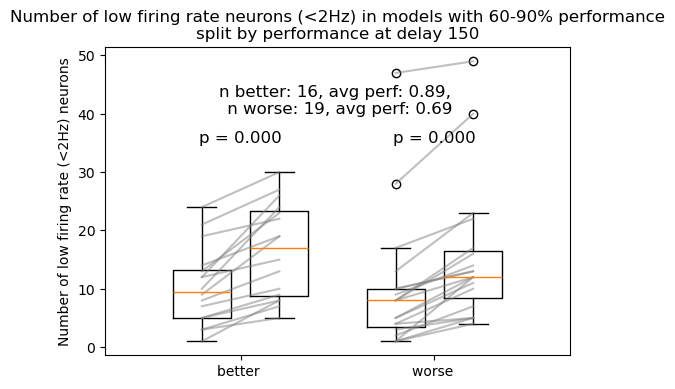

In [17]:
# make paired boxplot, now split by better/worse

plt.figure(figsize=(6,4))
plt.boxplot([num_lowfr_50[better_idx], num_lowfr_150[better_idx]], positions=[0.8, 1.2], widths=0.3)
plt.boxplot([num_lowfr_50[worse_idx], num_lowfr_150[worse_idx]], positions=[1.8, 2.2], widths=0.3)
# draw gray lines for each pair
for i in range(len(better_idx)):
    plt.plot([0.8, 1.2], [num_lowfr_50[better_idx[i]], num_lowfr_150[better_idx[i]]], color='gray', alpha=0.5)
for i in range(len(worse_idx)):
    plt.plot([1.8, 2.2], [num_lowfr_50[worse_idx[i]], num_lowfr_150[worse_idx[i]]], color='gray', alpha=0.5)
    
# do stats, wilcoxon signed-rank test for better and worse models
stat_better, pval_better = scipy.stats.wilcoxon(num_lowfr_50[better_idx], num_lowfr_150[better_idx])
stat_worse, pval_worse = scipy.stats.wilcoxon(num_lowfr_50[worse_idx], num_lowfr_150[worse_idx])
plt.text(1, 35, 'p = {:.3f}'.format(pval_better), fontsize=12, ha='center')
plt.text(2, 35, 'p = {:.3f}'.format(pval_worse), fontsize=12, ha='center')
plt.text(1.5, 40, f'n better: {len(better_idx)}, avg perf: {np.mean(bad_perfs[better_idx]):.2f}, \n n worse: {len(worse_idx)}, avg perf: {np.mean(bad_perfs[worse_idx]):.2f}',
         fontsize=12, ha='center')
    
plt.ylabel('Number of low firing rate (<2Hz) neurons')
plt.title('Number of low firing rate neurons (<2Hz) in models with 60-90% performance\n'
          'split by performance at delay 150')
plt.xticks([1, 2], ['better ', 'worse '], rotation=0)

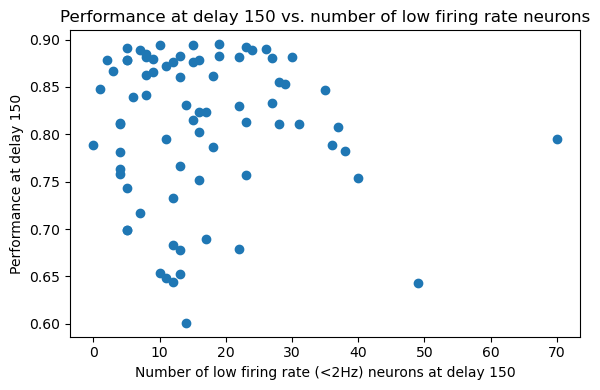

In [18]:
plt.figure(figsize=(6,4))
plt.scatter(num_lowfr_150, bad_perfs)
plt.xlabel('Number of low firing rate (<2Hz) neurons at delay 150')
plt.ylabel('Performance at delay 150')
plt.title('Performance at delay 150 vs. number of low firing rate neurons')
plt.tight_layout()
plt.show()

In [19]:
perfs_50 = np.zeros(len(bad_models))
for i, model_name in enumerate(bad_models):
    _, perfs = ld.load_bhv_data(model_name, 'delay', condn_num=50)
    perfs_50[i] = np.mean(perfs)

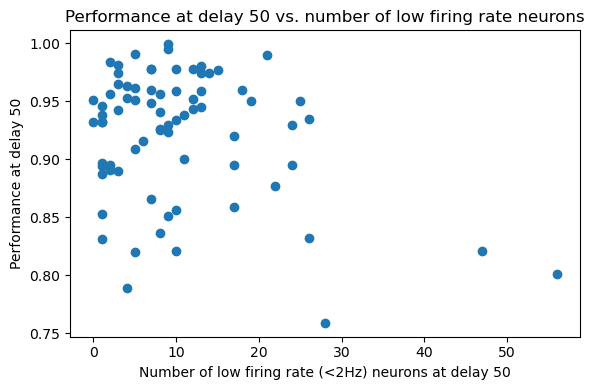

In [20]:
plt.figure(figsize=(6,4))
plt.scatter(num_lowfr_50, perfs_50)
plt.xlabel('Number of low firing rate (<2Hz) neurons at delay 50')
plt.ylabel('Performance at delay 50')
plt.title('Performance at delay 50 vs. number of low firing rate neurons')
plt.tight_layout()
plt.show()

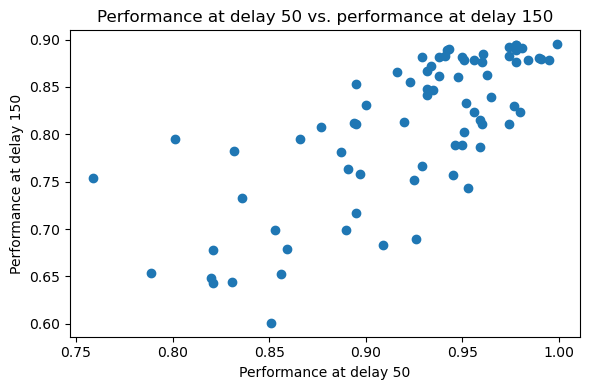

In [21]:
plt.figure(figsize=(6,4))
plt.scatter(perfs_50, bad_perfs)
plt.xlabel('Performance at delay 50')
plt.ylabel('Performance at delay 150')
plt.title('Performance at delay 50 vs. performance at delay 150')
plt.tight_layout()
plt.show()

## now do models between 60-100% accuracy on delay 150

In [22]:
model_names, perfs_150 = ld.get_models_by_perf(low_cutoff=0.60, high_cutoff=np.inf,
                                                condn_phrase='delay', condn_num=150)
perfs_50 = np.zeros(len(model_names))
for i, model_name in enumerate(model_names):
    _, perfs = ld.load_bhv_data(model_name, 'delay', condn_num=50)
    perfs_50[i] = np.mean(perfs)

Found 141 models with performance between 0.6 and inf


In [23]:
num_lowfr_50 = np.zeros(len(model_names))
num_lowfr_150 = np.zeros(len(model_names))
for i, model_name in enumerate(model_names):
    lowfr_50 = ld.load_lowfr_idxs(model_name, 'delay', condn_num=50, threshold=2)
    lowfr_150 = ld.load_lowfr_idxs(model_name, 'delay', condn_num=150, threshold=2)
    num_lowfr_50[i] = len(lowfr_50)
    num_lowfr_150[i] = len(lowfr_150)

No files found with keywords ['lowfr', 'delay150', '2'] in /home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815
No files found with keywords ['lowfr', 'delay50', '2'] in /home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818
No files found with keywords ['lowfr', 'delay50', '2'] in /home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225459
No files found with keywords ['lowfr', 'delay150', '2'] in /home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225459
No files found with keywords ['lowfr', 'delay50', '2'] in /home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_221440
No files found with keywords ['lowfr', 'delay150', '2'] in /home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_221440
No file

Wilcoxon signed-rank test: stat = 5.0 , pval = 1.3982224863880847e-24


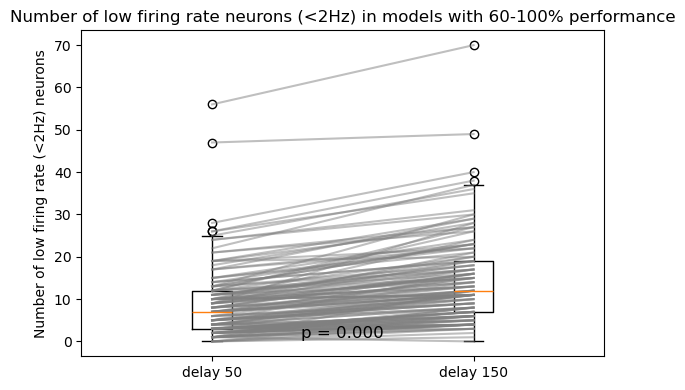

In [ ]:
# make paired boxplot
plt.figure(figsize=(6,4))
plt.boxplot([num_lowfr_50, num_lowfr_150])

# draw gray lines for each pair
for i in range(len(num_lowfr_50)):
    plt.plot([1, 2], [num_lowfr_50[i], num_lowfr_150[i]], color='gray', alpha=0.5)

plt.ylabel('Number of low firing rate (<2Hz) neurons')
plt.title('Number of low firing rate neurons (<2Hz) in models with 60-100% performance')
plt.xticks([1, 2], ['delay 50', 'delay 150'])

# do stats, wilcoxon signed-rank test
stat, pval = scipy.stats.wilcoxon(num_lowfr_50, num_lowfr_150)
print('Wilcoxon signed-rank test: stat =', stat, ', pval =', pval)
plt.text(1.5, 0.9, 'p = {:.3f}'.format(pval), fontsize=12, ha='center')

plt.tight_layout()
plt.show()

In [26]:
# split up by how much worse models are at delay 150 — split by percentile

better_idx = np.where(perfs_150 > np.percentile(perfs_150, 75))[0].astype(int)
worse_idx = np.where(perfs_150 < np.percentile(perfs_150, 25))[0].astype(int)

print(f'Number of models better at delay 150: {len(better_idx)}, avg perf: {np.mean(perfs_150[better_idx]):.2f}')
print(f'Number of models worse at delay 150: {len(worse_idx)}, avg perf: {np.mean(perfs_150[worse_idx]):.2f}')

Number of models better at delay 150: 34, avg perf: 0.98
Number of models worse at delay 150: 35, avg perf: 0.74


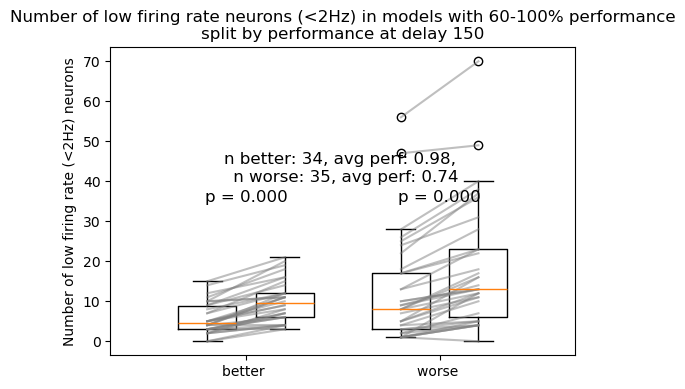

In [27]:
# make paired boxplot, now split by better/worse

plt.figure(figsize=(6,4))
plt.boxplot([num_lowfr_50[better_idx], num_lowfr_150[better_idx]], positions=[0.8, 1.2], widths=0.3)
plt.boxplot([num_lowfr_50[worse_idx], num_lowfr_150[worse_idx]], positions=[1.8, 2.2], widths=0.3)
# draw gray lines for each pair
for i in range(len(better_idx)):
    plt.plot([0.8, 1.2], [num_lowfr_50[better_idx[i]], num_lowfr_150[better_idx[i]]], color='gray', alpha=0.5)
for i in range(len(worse_idx)):
    plt.plot([1.8, 2.2], [num_lowfr_50[worse_idx[i]], num_lowfr_150[worse_idx[i]]], color='gray', alpha=0.5)
    
# do stats, wilcoxon signed-rank test for better and worse models
stat_better, pval_better = scipy.stats.wilcoxon(num_lowfr_50[better_idx], num_lowfr_150[better_idx])
stat_worse, pval_worse = scipy.stats.wilcoxon(num_lowfr_50[worse_idx], num_lowfr_150[worse_idx])
plt.text(1, 35, 'p = {:.3f}'.format(pval_better), fontsize=12, ha='center')
plt.text(2, 35, 'p = {:.3f}'.format(pval_worse), fontsize=12, ha='center')
plt.text(1.5, 40, f'n better: {len(better_idx)}, avg perf: {np.mean(perfs_150[better_idx]):.2f}, \n n worse: {len(worse_idx)}, avg perf: {np.mean(perfs_150[worse_idx]):.2f}',
         fontsize=12, ha='center')
    
plt.ylabel('Number of low firing rate (<2Hz) neurons')
plt.title('Number of low firing rate neurons (<2Hz) in models with 60-100% performance\n'
          'split by performance at delay 150')
plt.xticks([1, 2], ['better ', 'worse '], rotation=0)
plt.show()

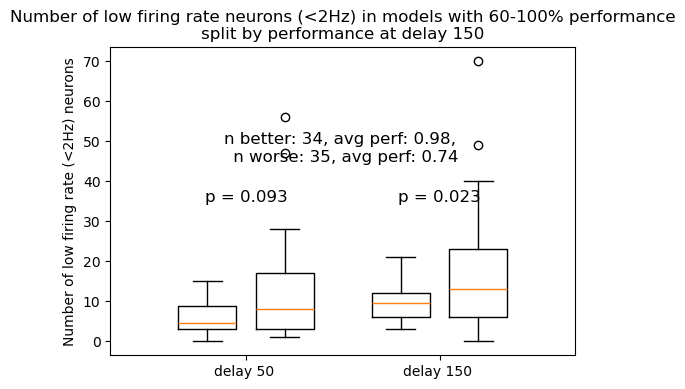

In [41]:
# make paired boxplot, now split by better/worse

plt.figure(figsize=(6,4))
plt.boxplot([num_lowfr_50[better_idx], num_lowfr_50[worse_idx]], positions=[0.8, 1.2], widths=0.3)
plt.boxplot([num_lowfr_150[better_idx], num_lowfr_150[worse_idx]], positions=[1.8, 2.2], widths=0.3)
    
# do stats, mann whitney
stat_50, pval_50 = scipy.stats.mannwhitneyu(num_lowfr_50[better_idx], num_lowfr_50[worse_idx])
stat_150, pval_150 = scipy.stats.mannwhitneyu(num_lowfr_150[better_idx], num_lowfr_150[worse_idx])

plt.text(1, 35, 'p = {:.3f}'.format(pval_50), fontsize=12, ha='center')
plt.text(2, 35, 'p = {:.3f}'.format(pval_150), fontsize=12, ha='center')
plt.text(1.5, 45, f'n better: {len(better_idx)}, avg perf: {np.mean(perfs_150[better_idx]):.2f}, \n n worse: {len(worse_idx)}, avg perf: {np.mean(perfs_150[worse_idx]):.2f}',
         fontsize=12, ha='center')
    
plt.ylabel('Number of low firing rate (<2Hz) neurons')
plt.title('Number of low firing rate neurons (<2Hz) in models with 60-100% performance\n'
          'split by performance at delay 150')
plt.xticks([1, 2], ['delay 50 ', 'delay 150 '], rotation=0)
plt.show()

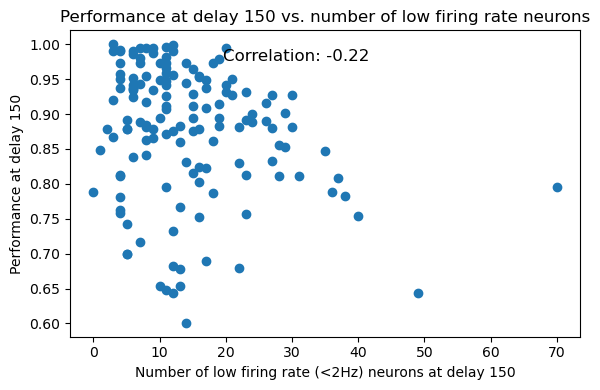

In [31]:
plt.figure(figsize=(6,4))
plt.scatter(num_lowfr_150, perfs_150)

# calculate correlation and plot it
corr_coef = np.corrcoef(num_lowfr_150, perfs_150)[0, 1]
plt.text(.3, 0.9, f'Correlation: {corr_coef:.2f}', fontsize=12, transform=plt.gca().transAxes)


plt.xlabel('Number of low firing rate (<2Hz) neurons at delay 150')
plt.ylabel('Performance at delay 150')
plt.title('Performance at delay 150 vs. number of low firing rate neurons')
plt.tight_layout()
plt.show()

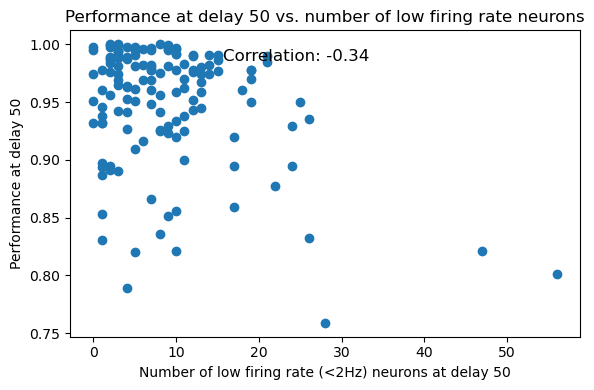

In [33]:
plt.figure(figsize=(6,4))
plt.scatter(num_lowfr_50, perfs_50)

# correlation
corr_coef = np.corrcoef(num_lowfr_50, perfs_50)[0, 1]
plt.text(.3, 0.9, f'Correlation: {corr_coef:.2f}', fontsize=12, transform=plt.gca().transAxes)

plt.xlabel('Number of low firing rate (<2Hz) neurons at delay 50')
plt.ylabel('Performance at delay 50')
plt.title('Performance at delay 50 vs. number of low firing rate neurons')
plt.tight_layout()
plt.show()

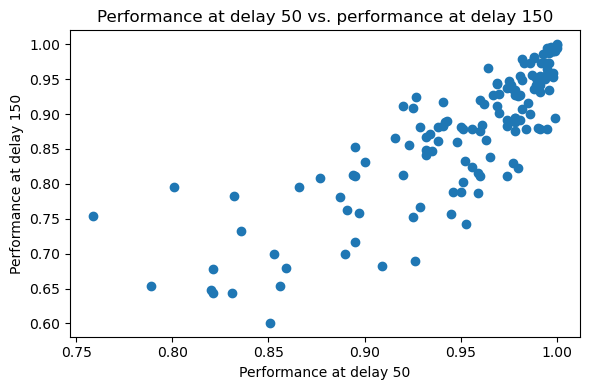

In [35]:
plt.figure(figsize=(6,4))
plt.scatter(perfs_50, perfs_150)
plt.xlabel('Performance at delay 50')
plt.ylabel('Performance at delay 150')
plt.title('Performance at delay 50 vs. performance at delay 150')
plt.tight_layout()
plt.show()

## now do models with >95% accuracy on delay 50

In [42]:
model_names, perfs_50 = ld.get_models_by_perf(low_cutoff=0.95, high_cutoff=np.inf,
                                                condn_phrase='delay', condn_num=50)

perfs_150 = np.zeros(len(model_names))
for i, model_name in enumerate(model_names):
    _, perfs = ld.load_bhv_data(model_name, 'delay', condn_num=150)
    perfs_150[i] = np.mean(perfs)

Found 90 models with performance between 0.95 and inf


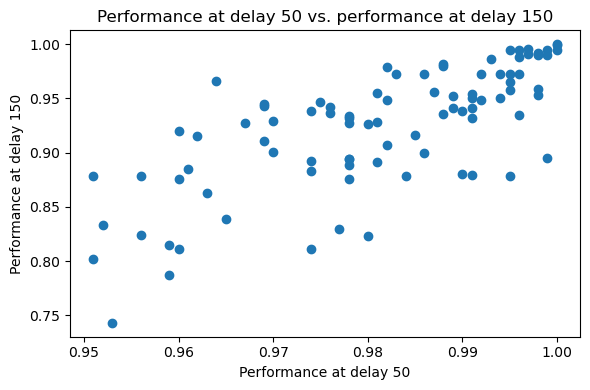

In [43]:
plt.figure(figsize=(6,4))
plt.scatter(perfs_50, perfs_150)
plt.xlabel('Performance at delay 50')
plt.ylabel('Performance at delay 150')
plt.title('Performance at delay 50 vs. performance at delay 150')
plt.tight_layout()
plt.show()

In [44]:
num_lowfr_50 = np.zeros(len(model_names))
num_lowfr_150 = np.zeros(len(model_names))
for i, model_name in enumerate(model_names):
    lowfr_50 = ld.load_lowfr_idxs(model_name, 'delay', condn_num=50, threshold=2)
    lowfr_150 = ld.load_lowfr_idxs(model_name, 'delay', condn_num=150, threshold=2)
    num_lowfr_50[i] = len(lowfr_50)
    num_lowfr_150[i] = len(lowfr_150)

Wilcoxon signed-rank test: stat = 0.0 , pval = 3.259825896945611e-16


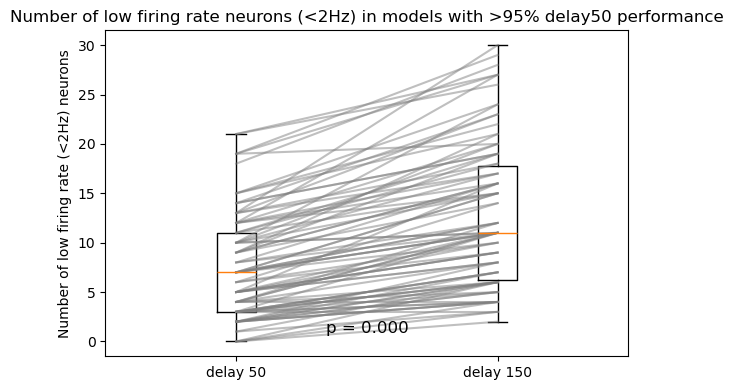

In [45]:
# make paired boxplot
plt.figure(figsize=(6,4))
plt.boxplot([num_lowfr_50, num_lowfr_150])

# draw gray lines for each pair
for i in range(len(num_lowfr_50)):
    plt.plot([1, 2], [num_lowfr_50[i], num_lowfr_150[i]], color='gray', alpha=0.5)

plt.ylabel('Number of low firing rate (<2Hz) neurons')
plt.title('Number of low firing rate neurons (<2Hz) in models with >95% delay50 performance')
plt.xticks([1, 2], ['delay 50', 'delay 150'])

# do stats, wilcoxon signed-rank test
stat, pval = scipy.stats.wilcoxon(num_lowfr_50, num_lowfr_150)
print('Wilcoxon signed-rank test: stat =', stat, ', pval =', pval)
plt.text(1.5, 0.9, 'p = {:.3f}'.format(pval), fontsize=12, ha='center')

plt.tight_layout()
plt.show()

In [46]:
# split up by how much worse models are at delay 150 — split by percentile

better_idx = np.where(perfs_150 > np.percentile(perfs_150, 75))[0].astype(int)
worse_idx = np.where(perfs_150 < np.percentile(perfs_150, 25))[0].astype(int)

print(f'Number of models better at delay 150: {len(better_idx)}, avg perf: {np.mean(perfs_150[better_idx]):.2f}')
print(f'Number of models worse at delay 150: {len(worse_idx)}, avg perf: {np.mean(perfs_150[worse_idx]):.2f}')

Number of models better at delay 150: 23, avg perf: 0.99
Number of models worse at delay 150: 23, avg perf: 0.85


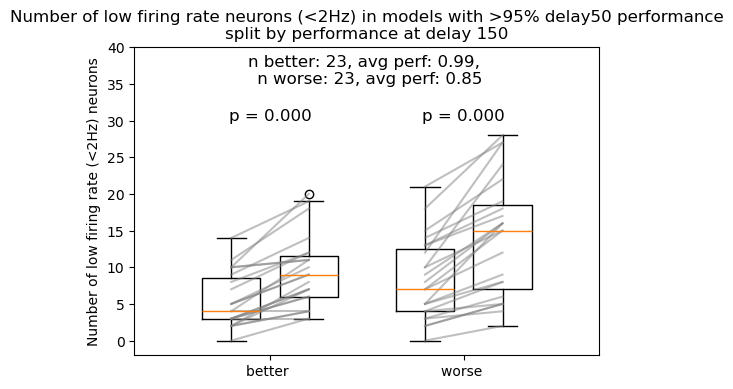

In [48]:
# make paired boxplot, now split by better/worse

plt.figure(figsize=(6,4))
plt.boxplot([num_lowfr_50[better_idx], num_lowfr_150[better_idx]], positions=[0.8, 1.2], widths=0.3)
plt.boxplot([num_lowfr_50[worse_idx], num_lowfr_150[worse_idx]], positions=[1.8, 2.2], widths=0.3)
# draw gray lines for each pair
for i in range(len(better_idx)):
    plt.plot([0.8, 1.2], [num_lowfr_50[better_idx[i]], num_lowfr_150[better_idx[i]]], color='gray', alpha=0.5)
for i in range(len(worse_idx)):
    plt.plot([1.8, 2.2], [num_lowfr_50[worse_idx[i]], num_lowfr_150[worse_idx[i]]], color='gray', alpha=0.5)
    
# do stats, wilcoxon signed-rank test for better and worse models
stat_better, pval_better = scipy.stats.wilcoxon(num_lowfr_50[better_idx], num_lowfr_150[better_idx])
stat_worse, pval_worse = scipy.stats.wilcoxon(num_lowfr_50[worse_idx], num_lowfr_150[worse_idx])
plt.text(1, 30, 'p = {:.3f}'.format(pval_better), fontsize=12, ha='center')
plt.text(2, 30, 'p = {:.3f}'.format(pval_worse), fontsize=12, ha='center')
plt.text(1.5, 35, f'n better: {len(better_idx)}, avg perf: {np.mean(perfs_150[better_idx]):.2f}, \n n worse: {len(worse_idx)}, avg perf: {np.mean(perfs_150[worse_idx]):.2f}',
         fontsize=12, ha='center')
plt.ylim(-2, 40)
    
plt.ylabel('Number of low firing rate (<2Hz) neurons')
plt.title('Number of low firing rate neurons (<2Hz) in models with >95% delay50 performance\n'
          'split by performance at delay 150')
plt.xticks([1, 2], ['better ', 'worse '], rotation=0)
plt.show()

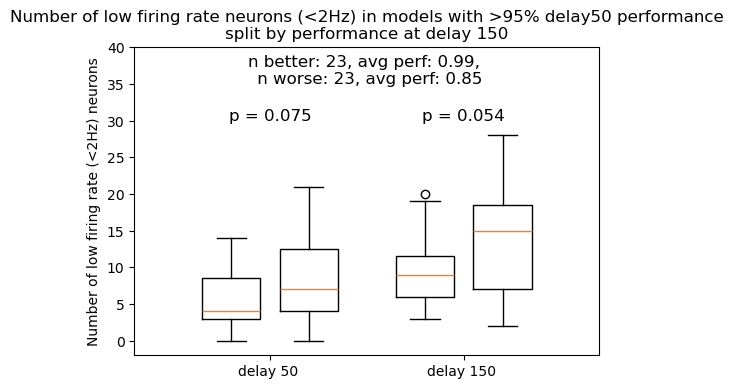

In [50]:
# make paired boxplot, now split by better/worse

plt.figure(figsize=(6,4))
plt.boxplot([num_lowfr_50[better_idx], num_lowfr_50[worse_idx]], positions=[0.8, 1.2], widths=0.3)
plt.boxplot([num_lowfr_150[better_idx], num_lowfr_150[worse_idx]], positions=[1.8, 2.2], widths=0.3)
    
# do stats, mann whitney
stat_50, pval_50 = scipy.stats.mannwhitneyu(num_lowfr_50[better_idx], num_lowfr_50[worse_idx])
stat_150, pval_150 = scipy.stats.mannwhitneyu(num_lowfr_150[better_idx], num_lowfr_150[worse_idx])

plt.text(1, 30, 'p = {:.3f}'.format(pval_50), fontsize=12, ha='center')
plt.text(2, 30, 'p = {:.3f}'.format(pval_150), fontsize=12, ha='center')
plt.text(1.5, 35, f'n better: {len(better_idx)}, avg perf: {np.mean(perfs_150[better_idx]):.2f}, \n n worse: {len(worse_idx)}, avg perf: {np.mean(perfs_150[worse_idx]):.2f}',
         fontsize=12, ha='center')
plt.ylim(-2, 40)
    
plt.ylabel('Number of low firing rate (<2Hz) neurons')
plt.title('Number of low firing rate neurons (<2Hz) in models with >95% delay50 performance\n'
          'split by performance at delay 150')
plt.xticks([1, 2], ['delay 50 ', 'delay 150 '], rotation=0)
plt.show()

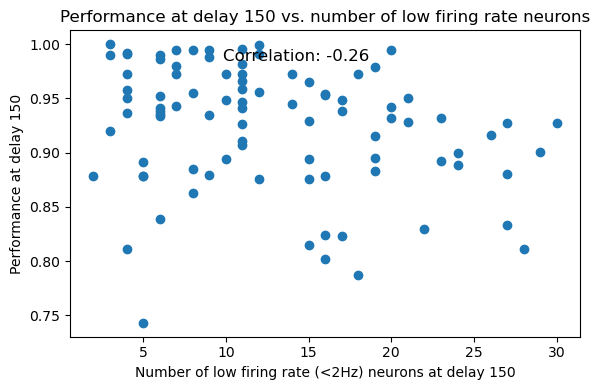

In [51]:
plt.figure(figsize=(6,4))
plt.scatter(num_lowfr_150, perfs_150)

# calculate correlation and plot it
corr_coef = np.corrcoef(num_lowfr_150, perfs_150)[0, 1]
plt.text(.3, 0.9, f'Correlation: {corr_coef:.2f}', fontsize=12, transform=plt.gca().transAxes)


plt.xlabel('Number of low firing rate (<2Hz) neurons at delay 150')
plt.ylabel('Performance at delay 150')
plt.title('Performance at delay 150 vs. number of low firing rate neurons')
plt.tight_layout()
plt.show()

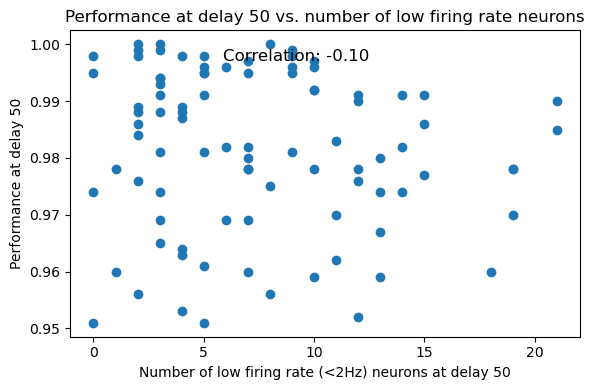

In [52]:
plt.figure(figsize=(6,4))
plt.scatter(num_lowfr_50, perfs_50)

# correlation
corr_coef = np.corrcoef(num_lowfr_50, perfs_50)[0, 1]
plt.text(.3, 0.9, f'Correlation: {corr_coef:.2f}', fontsize=12, transform=plt.gca().transAxes)

plt.xlabel('Number of low firing rate (<2Hz) neurons at delay 50')
plt.ylabel('Performance at delay 50')
plt.title('Performance at delay 50 vs. number of low firing rate neurons')
plt.tight_layout()
plt.show()